In [1]:
import sys
sys.path.append("../src")

In [ ]:
import pandas as pd

import readers as readers

DATA_DIR = "../assets/data"

In [3]:
dfs: dict[str, pd.DataFrame] = readers.load_csv(DATA_DIR)
dfs.keys()

d:\!Projects\Python\USHIET-DATATHON26\notebooks\../src\readers.py:8: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  osp.split(csv)[-1][:-4]: pd.read_csv(csv)


dict_keys(['customers', 'geography', 'inventory', 'orders', 'order_items', 'payments', 'products', 'promotions', 'returns', 'reviews', 'sales', 'shipments', 'web_traffic'])

# Q1 - C?

In [24]:
orders = dfs["orders"].copy()
orders["order_date"] = pd.to_datetime(orders["order_date"])

In [25]:
inter_days = orders.groupby("customer_id").agg(
    counts=("order_id", "count"),
    min_date=("order_date", "min"),
    max_date=("order_date", "max"),
    inter_days=("order_date", lambda row: row.sort_values().diff().iloc[1:])
)
exploded = inter_days[inter_days["counts"] > 1].explode("inter_days")

Median inter-arrival days: 144


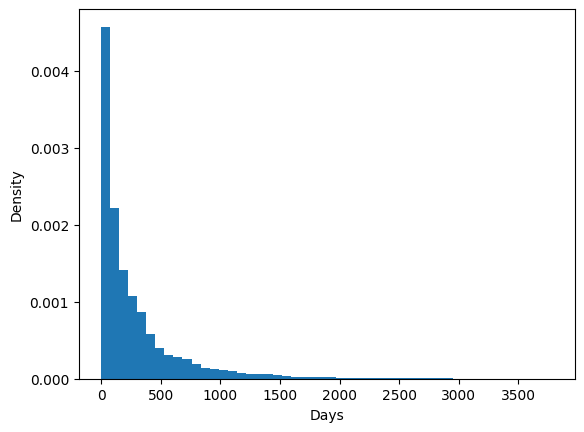

In [69]:
exploded["inter_days"].dt.days.plot.hist(
    bins=50,
    density=True,
    xlabel="Days",
    ylabel="Density"
)

print(f"Median inter-arrival days: \033[1m{exploded["inter_days"].median().days}\033[0m")

# Q2 - D

In [36]:
products = dfs["products"].copy()
products["ros"] = (products["price"] - products["cogs"]) / products["price"]

In [37]:
sums = products.groupby("segment").agg(
    price=("price", "sum"),
    cogs=("cogs", "sum")
)
ros = ((sums["price"] - sums["cogs"]) / sums["price"]).sort_values(ascending=False)

Maximum ROS segment: Standard


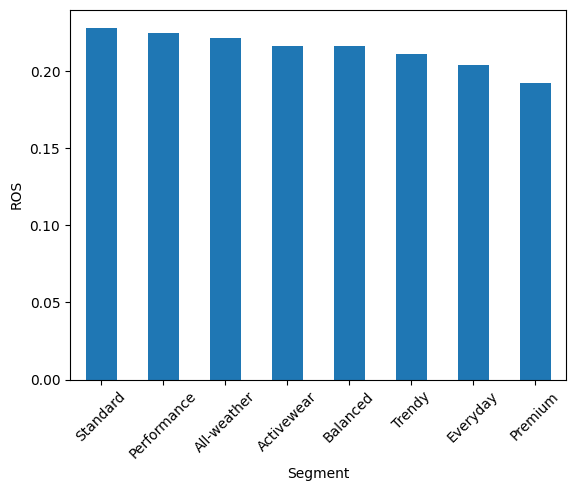

In [47]:
ros.plot.bar(
    rot=45,
    xlabel="Segment",
    ylabel="ROS"
)

print(f"Maximum ROS segment: \033[1m{ros.index[0]}\033[0m")

# Q3 - B

In [70]:
returns = dfs["returns"].copy()

In [71]:
returned_products = returns.rename(columns=lambda i: f"returns.{i}").merge(
    products.rename(columns=lambda x: f"products.{x}"),
    "left",
    left_on="returns.product_id",
    right_on="products.product_id",
)
ranked_reason = returned_products[returned_products["products.category"] == "Streetwear"].value_counts("returns.return_reason")

Most common return reason for Streetwear: wrong_size


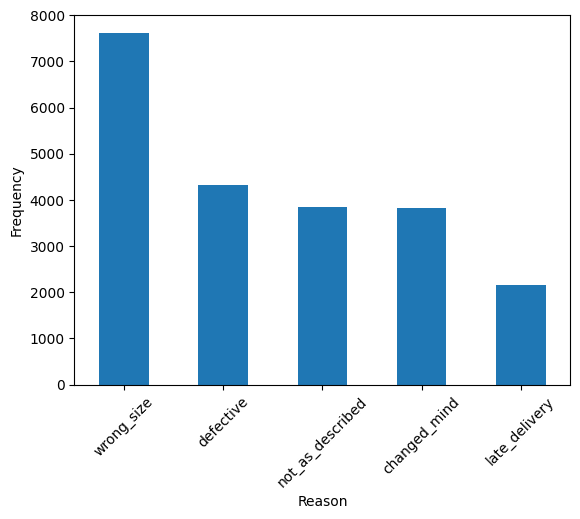

In [ ]:
ranked_reason.plot.bar(
    rot=45,
    xlabel="Reason",
    ylabel="Frequency"
)

print(f"Most common return reason for Streetwear: \033[1m{ranked_reason.index[0]}\033[0m")

# Q4 - C

In [73]:
web_traffic = dfs["web_traffic"].copy()
web_traffic["one_hit_session"] = web_traffic["bounce_rate"] * web_traffic["sessions"] 

In [ ]:
avg_bounce_rates = web_traffic.groupby("traffic_source").agg(
    one_hit_session=("one_hit_session", "sum"),
    sessions=("sessions", "sum"),
)
avg_bounce_rates["avg_br"] = avg_bounce_rates["one_hit_session"] / avg_bounce_rates["sessions"]
avg_bounce_rates.sort_values("avg_br", inplace=True)

Source with lowest avg bounce rate: email_campaign


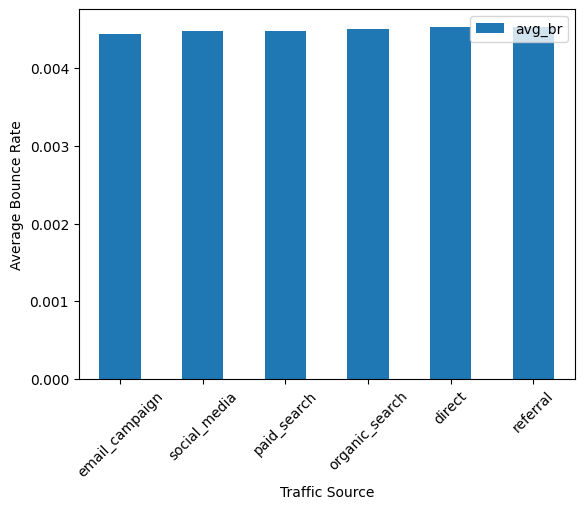

In [77]:
avg_bounce_rates.plot.bar(
    y="avg_br",
    rot=45,
    xlabel="Traffic Source",
    ylabel="Average Bounce Rate"
)

print(f"Source with lowest avg bounce rate: \033[1m{avg_bounce_rates.index[0]}\033[0m")

# Q5 - C

In [8]:
order_items = dfs["order_items"]
with_promotions = (~order_items["promo_id"].isna()).sum()
print(
    "Percentage of orders with promotions: "
    f"{with_promotions} / {len(order_items)} "
    f"= \033[1m{with_promotions/len(order_items):.2%}\033[0m"
)

Percentage of orders with promotions: 276316 / 714669 = 38.66%


# Q6 - A

In [81]:
customers = dfs["customers"].copy()
customers.dropna(subset=["age_group"], inplace=True)

In [82]:
orders_w_customers = orders.merge(
    customers.rename(columns=lambda i: f"customers.{i}"),
    left_on="customer_id",
    right_on="customers.customer_id"
)
groupby_age = orders_w_customers.groupby("customers.age_group").agg(
    num_orders=("order_id", "nunique"),
).merge(
    customers.value_counts("age_group"),
    "left", left_index=True, right_index=True
)
groupby_age["avg_orders"] = groupby_age["num_orders"] / groupby_age["count"]
groupby_age.sort_values("avg_orders", ascending=False, inplace=True)

Age group with highest number of orders per customer: 55+


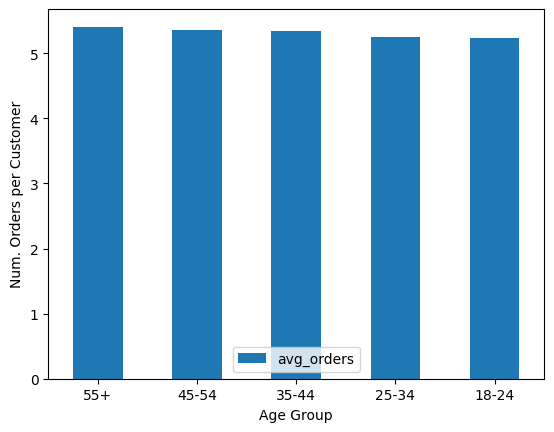

In [85]:
groupby_age.plot.bar(
    y="avg_orders",
    rot=0,
    xlabel="Age Group",
    ylabel="Num. Orders per Customer"
)

print(f"Age group with highest number of orders per customer: \033[1m{groupby_age.index[0]}\033[0m")

# Q7 - C?

In [86]:
geography = dfs["geography"].copy()

In [87]:
orders_w_zip = orders[["order_id", "zip"]].rename(columns=lambda i: f"orders.{i}").merge(
    geography.rename(columns=lambda i: f"geography.{i}"),
    left_on="orders.zip",
    right_on="geography.zip"
)
orders_w_items = order_items.rename(columns=lambda i: f"order_items.{i}").merge(
    orders_w_zip,
    left_on="order_items.order_id",
    right_on="orders.order_id"
)
orders_w_items["revenue"] = orders_w_items["order_items.quantity"] * orders_w_items["order_items.unit_price"]

total_rev = orders_w_items.groupby("geography.region").agg(
    total_revenue=("revenue", "sum")
).sort_values("total_revenue", ascending=False)

Region with highest revenue: East


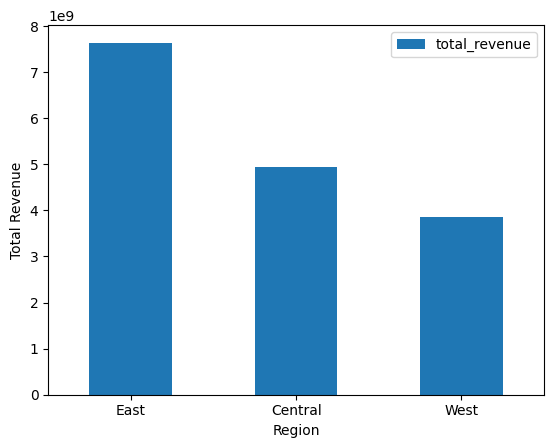

In [ ]:
total_rev.plot.bar(
    y="total_revenue",
    rot=0,
    xlabel="Region",
    ylabel="Total Revenue"
)

print(f"Region with highest revenue: \033[1m{total_rev.index[0]}\033[0m")

# Q8 - A

Most used payment method within cancelled orders: credit_card


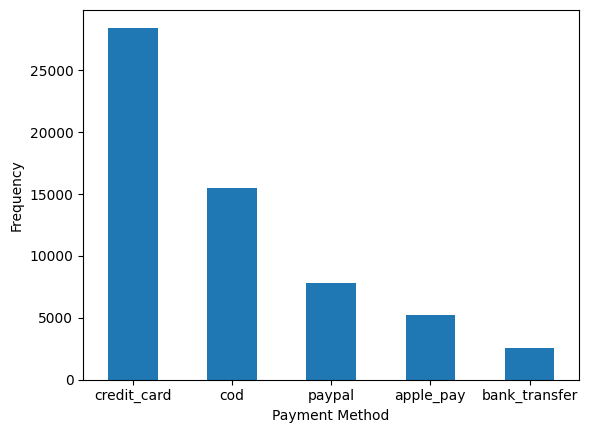

In [89]:
payment_methods = orders[orders["order_status"] == "cancelled"].value_counts("payment_method")
payment_methods.plot.bar(
    rot=0,
    xlabel="Payment Method",
    ylabel="Frequency"
)

print(f"Most used payment method within cancelled orders: \033[1m{payment_methods.index[0]}\033[0m")

# Q9 - B

In [90]:
groupby_size = returned_products.merge(
    order_items.value_counts("product_id"),
    left_on="returns.product_id",
    right_index=True
).groupby("products.size").agg(
    num_returns=("returns.return_id", "count"),
    num_order_items=("count", "sum")
)
groupby_size["return_ratio"] = groupby_size["num_returns"] / groupby_size["num_order_items"]
groupby_size.sort_values("return_ratio", ascending=False, inplace=True)

Size with highest return ratio: M


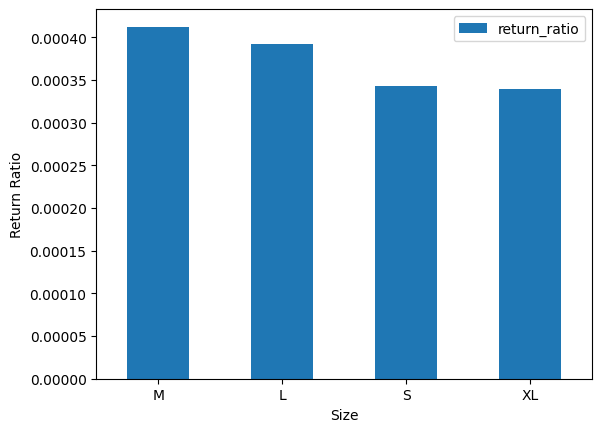

In [91]:
groupby_size.plot.bar(
    y="return_ratio",
    rot=0,
    xlabel="Size",
    ylabel="Return Ratio"
)

print(f"Size with highest return ratio: \033[1m{groupby_size.index[0]}\033[0m")

# Q10 - C

In [92]:
payments = dfs["payments"]

In [93]:
groupby_installments = payments.groupby("installments").agg(
    avg_payment_value=("payment_value", "mean")
).sort_values("avg_payment_value", ascending=False)

Installment with highest average payment value per order: 6


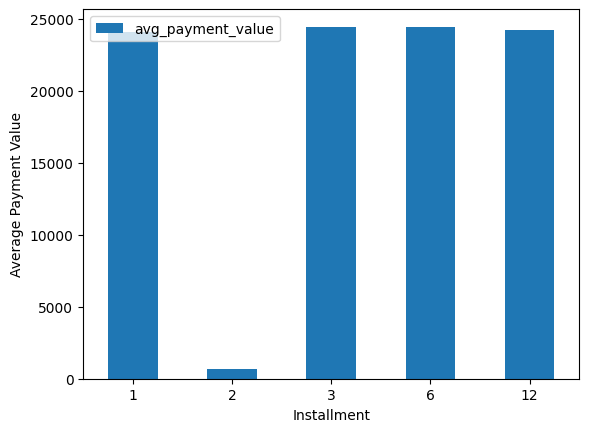

In [95]:
groupby_installments.sort_index().plot.bar(
    rot=0,
    xlabel="Installment",
    ylabel="Average Payment Value"
)

print(f"Installment with highest average payment value per order: \033[1m{groupby_installments.index[0]}\033[1m")